# 5 · From a story to a trained predictor

Trace the same two examples through an MLP and a one-layer attention model. Start
with data, not equations. Every numbered section has one calculation, an actual
numeric figure, and a link to its lecture slide. Run the cells in order.

The small calculation uses **B=2, w=4, C=10**. Its random weights are not the
trained TinyStories model. The final comparison is explicitly labelled saved
experimental evidence. Download the complete folder so the helper modules are
beside this notebook. No GPU, dataset download or retraining is needed for this
walkthrough.

[Readable study guide](https://nipunbatra.github.io/attention/notebooks/wordlm/05_training_and_inference_maps.html)
· [Part II](https://nipunbatra.github.io/attention/attention.html?present#s19/4/0)


In [1]:
from slow_walkthrough import initial_namespace, show_figure
from IPython.display import HTML, display
from pathlib import Path
globals().update(initial_namespace())
display(HTML('<style>' + Path('lesson.css').read_text() + '</style>'))

<a id='data'></a>

## 01 · The data: complete short stories

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/5/0)

The saved experiment uses 6,000 TinyStories documents. Each document is a complete story. This is an excerpt from source row 12400.

Once upon a time, there lived a little bunny.
Source row: 12400


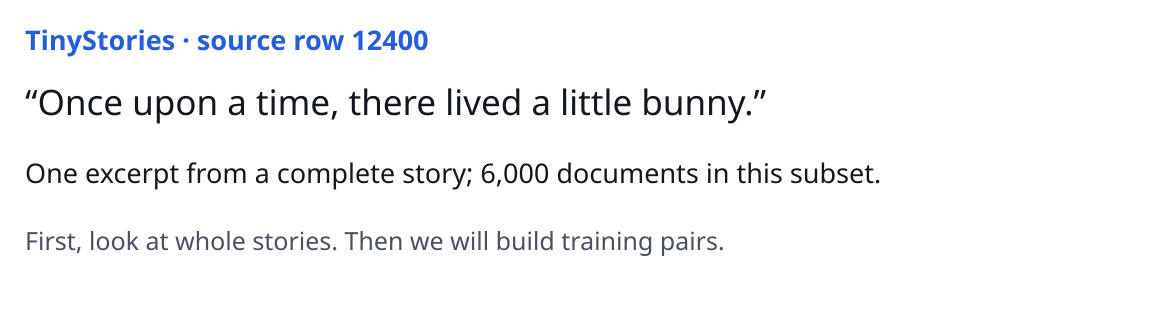

In [2]:
sample = evidence['sample']
print(sample['text_excerpt'])
print('Source row:', sample['row_idx'])

show_figure('data', globals())

<a id='story-complete'></a>

## 02 · Read one complete story

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/6/0)

One document is one complete story, not one sentence. This is the shortest story in our saved 6,000-document subset; many others are longer.

TinyStories · Ronen Eldan &amp; Yuanzhi Li · <a href="https://huggingface.co/datasets/roneneldan/TinyStories">source dataset</a> · <a href="https://cdla.dev/sharing-1-0/">CDLA-Sharing-1.0</a>

Three unchanged source texts are included in `story_examples.json`, with revision, row IDs and checksums. Display labels are ours; […] marks omitted text in the figure. The code below prints the complete text and recomputes the lengths.

Once upon a time, there was an old hotel. The hotel was very big and had many rooms. One day, a big storm came and lightning struck the hotel. The hotel was very old and could not handle the strike. The hotel fell down and everyone had to go home. The end.
Full story: 52 words; 60 tokens.


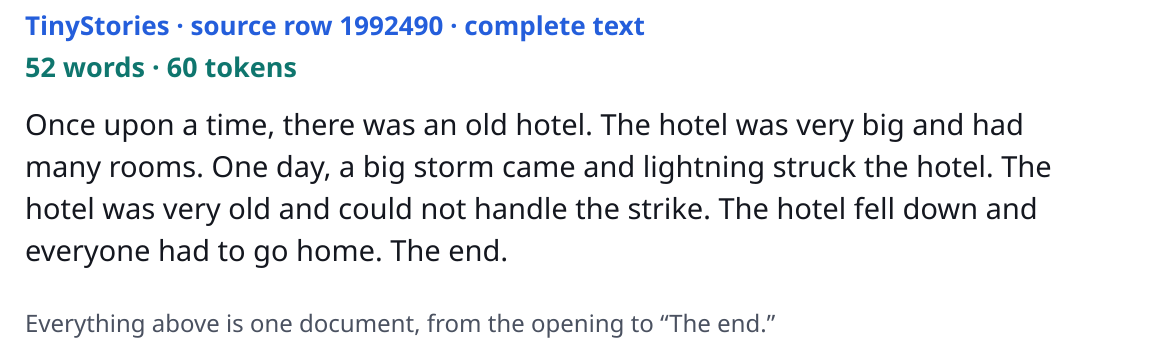

In [3]:
short_story = story_examples['examples'][0]
short_words = len(short_story['text'].split())
short_tokens = len(tokenize(short_story['text']))
assert (short_words, short_tokens) == (52, 60)
print(short_story['text'])
print(f'Full story: {short_words} words; {short_tokens} tokens.')

show_figure('story-complete', globals())

<a id='story-excerpts'></a>

## 03 · Longer stories have several paragraphs

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/7/0)

These beginnings and endings come from two other documents in the same subset. […] marks omitted text; the lengths count each whole story. Words are whitespace-separated items; tokens also separate punctuation and exclude start/end markers.

TinyStories · Ronen Eldan &amp; Yuanzhi Li · <a href="https://huggingface.co/datasets/roneneldan/TinyStories">source dataset</a> · <a href="https://cdla.dev/sharing-1-0/">CDLA-Sharing-1.0</a>

Three unchanged source texts are included in `story_examples.json`, with revision, row IDs and checksums. Display labels are ours; […] marks omitted text in the figure. The code below prints the complete text and recomputes the lengths.

<details><summary>Check yourself: Is a 300-token story a single 64-token training input?</summary>No. A story is a document. Later, we turn it into many next-token examples, each using at most the previous 64 tokens in the saved experiment.</details>

Source row 12400: 107 words; 133 tokens
Once upon a time, there lived a little bunny. The bunny loved carrots, so every day the bunny went outside to find carrots. One day, the bunny was looking for some carrots and came across something strange. It looked like a weird rock.

The bunny hopped closer and asked, "What are you?"

The rock replied, "I'm a weird carrot!"

The bunny was very surprised and said, "Weird carrots don't exist!"

But the rock said, "Oh yes they do! I'm a cool carrot that always rocks!"

The bunny was amazed. He thanked the rock for the new and weird carrot and hopped away to find more delicious snacks.

Source row 588307: 248 words; 300 tokens
Sara and Tom were playing with their crayons and paper. They liked to draw animals and flowers and cars. Sara was drawing a big red pepper, because she liked to eat peppers. Tom was drawing a blue fish, because he liked to swim.

"Look at my pepper!" Sara said to Tom. "It is very pretty and shiny. Do you like it?"

Tom looke

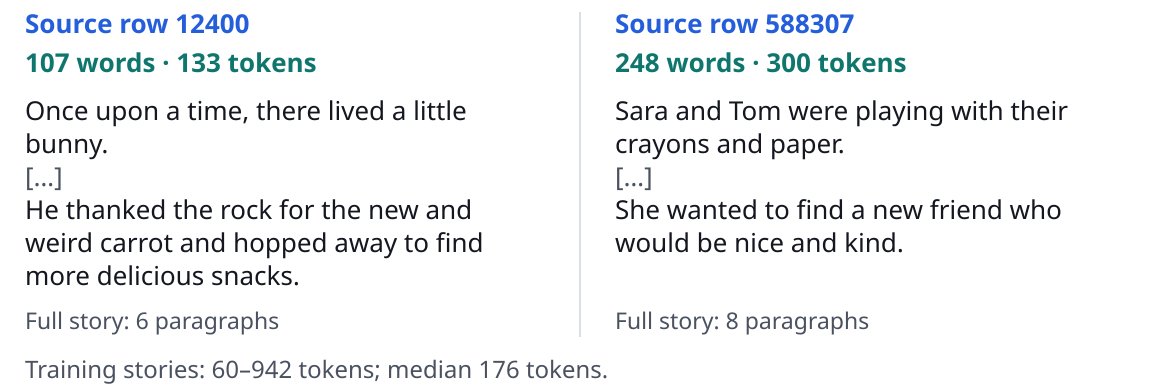

In [4]:
long_stories = story_examples['examples'][1:]
story_lengths = []
for story in long_stories:
    counts = (len(story['text'].split()), len(tokenize(story['text'])))
    assert counts == (story['word_count'], story['token_count'])
    story_lengths.append(counts)
    print(f"Source row {story['row_idx']}: {counts[0]} words; {counts[1]} tokens")
    print(story['text'] + '\n')  # full texts here; excerpts in the figure
train_lengths = evidence['audit']['story_length_tokens']['train']
print('Training-story token lengths:', train_lengths)

show_figure('story-excerpts', globals())

<a id='split'></a>

## 04 · Stories stay together when we split the data

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/8/0)

The split happens before overlapping windows are made. Training fits parameters and the vocabulary. Validation chooses settings and checkpoints. Test measures the frozen choice.

{'test': 592, 'train': 4822, 'validation': 586}


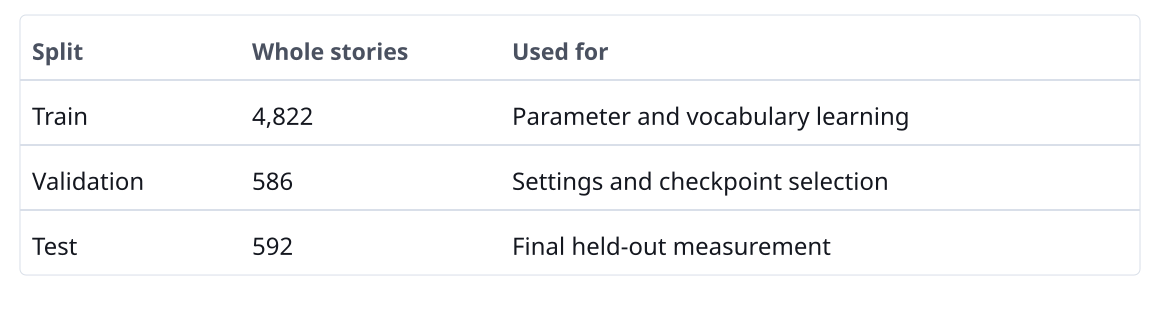

In [5]:
audit = evidence['audit']
print(audit['documents'])
assert sum(audit['documents'].values()) == 6000
assert not any(audit['document_overlap'].values())

show_figure('split', globals())

<a id='sentence'></a>

## 05 · A sentence we can trace completely

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/9/0)

We use this authored sentence for the arithmetic. Its small vocabulary and randomly initialized models are separate from the measured TinyStories experiment.

Lily found a red ball.


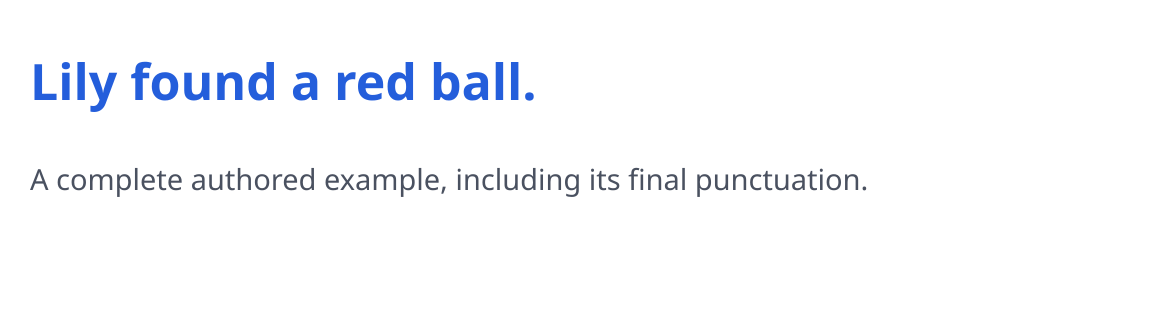

In [6]:
sentence = 'Lily found a red ball.'
print(sentence)

show_figure('sentence', globals())

<a id='tokenize'></a>

## 06 · Lowercase words and separate punctuation

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/10/0)

This tokenizer normalizes Unicode, lowercases text and keeps punctuation as tokens. Five words plus the full stop give six tokens. A tokenizer decides what one prediction unit is.

['lily', 'found', 'a', 'red', 'ball', '.']


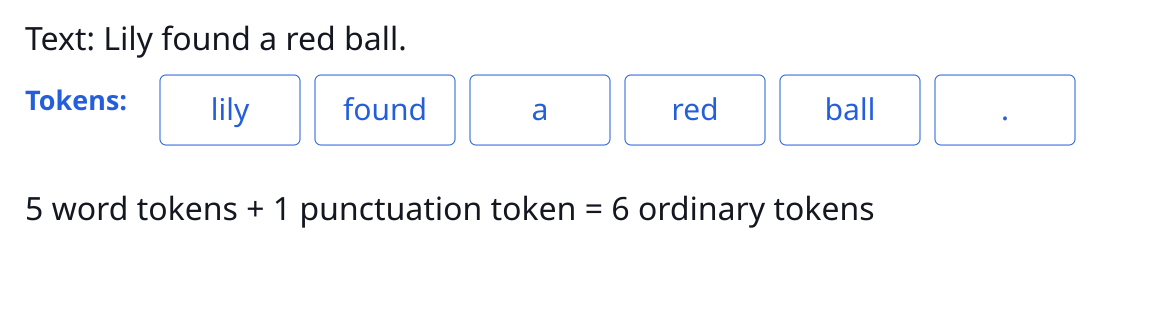

In [7]:
pieces = tokenize(sentence)
print(pieces)
assert pieces == ['lily', 'found', 'a', 'red', 'ball', '.']
assert len(pieces) == 6

show_figure('tokenize', globals())

<a id='vocabulary'></a>

## 07 · Every vocabulary item gets an integer ID

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/11/0)

Our demonstration has six ordinary tokens and four special tokens, so C=10. IDs are arbitrary labels. The benchmark uses a different, frequency-ranked vocabulary with C=4,000.

{'<PAD>': 0, '<BOS>': 1, '<EOS>': 2, '<UNK>': 3, '.': 4, 'a': 5, 'ball': 6, 'found': 7, 'lily': 8, 'red': 9}


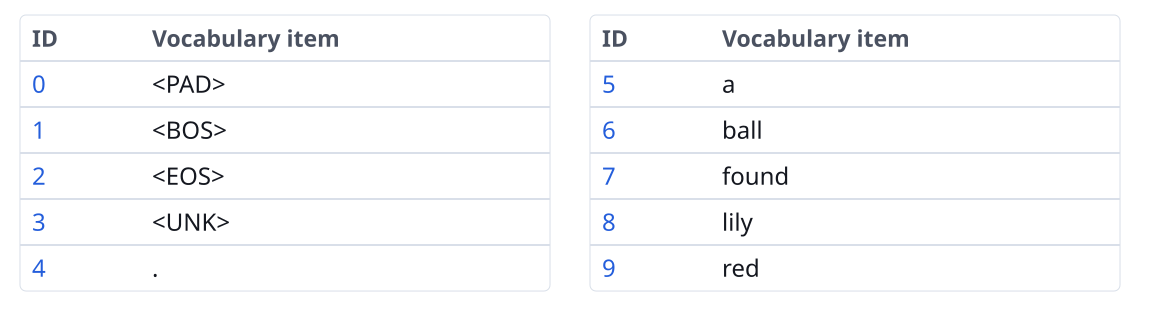

In [8]:
words = list(SPECIAL_TOKENS) + sorted(set(pieces))
vocab = Vocabulary(words, {t:i for i,t in enumerate(words)}, {}, 10, 1)
C = len(words)
assert C == 10
print(vocab.stoi)

show_figure('vocabulary', globals())

<a id='special'></a>

## 08 · Four special tokens have different jobs

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/12/0)

BOS marks the start of each story. EOS is an observed stopping target. PAD fills unused input slots. UNK represents a word missing from the fitted vocabulary.

blue maps to <UNK>


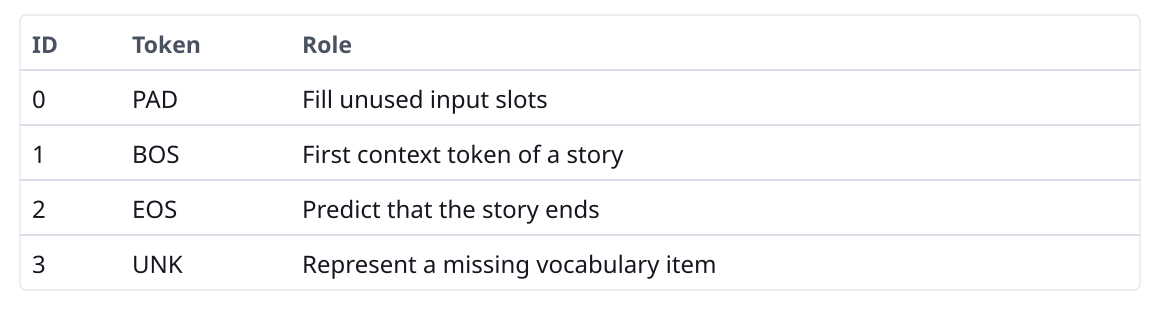

In [9]:
unknown = vocab.encode_tokens(tokenize('blue'), boundaries=False)
assert unknown == [vocab.unk_id]
print('blue maps to', words[unknown[0]])

show_figure('special', globals())

<a id='boundaries'></a>

## 09 · Add the story boundaries once

**1. Data and tokens** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/13/0)

There are now eight IDs: BOS, six ordinary tokens and EOS. We can ask for the next ID after each prefix. BOS is input context; it is not one of the seven targets.

<details><summary>Check yourself: How many ordinary tokens are there?</summary>Six. The full stop counts as one token; BOS and EOS are additional boundary tokens.</details>

[1, 8, 7, 5, 9, 6, 4, 2]


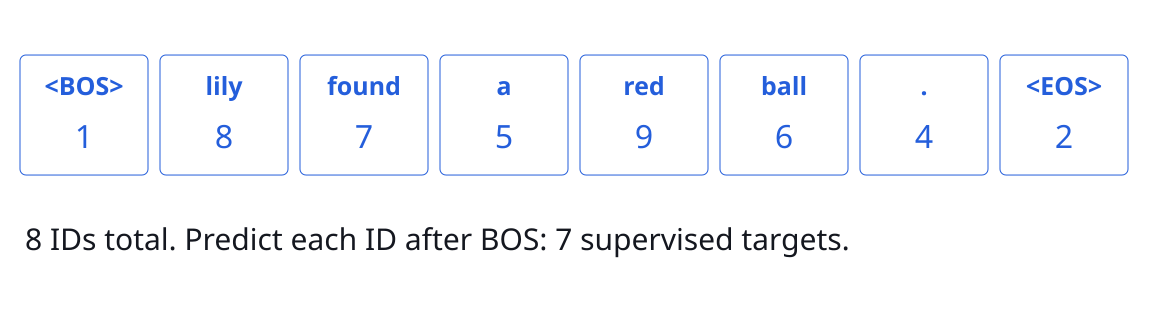

In [10]:
ids = vocab.encode_tokens(pieces)
print(ids)
assert ids == [1, 8, 7, 5, 9, 6, 4, 2]

show_figure('boundaries', globals())

<a id='one-pair'></a>

## 10 · One input window and its observed target

**2. Windows and batches** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/14/0)

At this point in the sentence, the next observed word is red. Its ID goes to the loss later. It is outside the model input for this example.

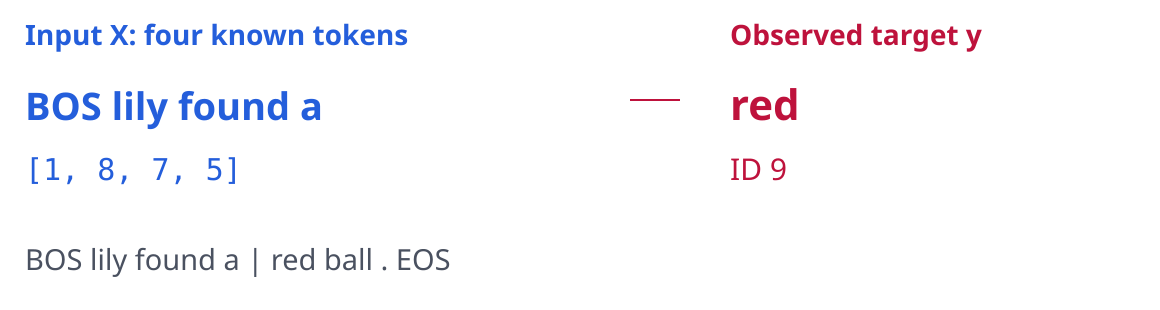

In [11]:
w = 4
target_position = 4
one_x = ids[target_position-w:target_position]
one_y = ids[target_position]
assert one_x == [1, 8, 7, 5] and one_y == 9

show_figure('one-pair', globals())

<a id='windows-first'></a>

## 11 · Early prefixes need padding

**2. Windows and batches** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/15/0)

The model always receives four slots. Left-padding preserves the most recent token in the final slot. These are the first four supervised examples from the sentence.

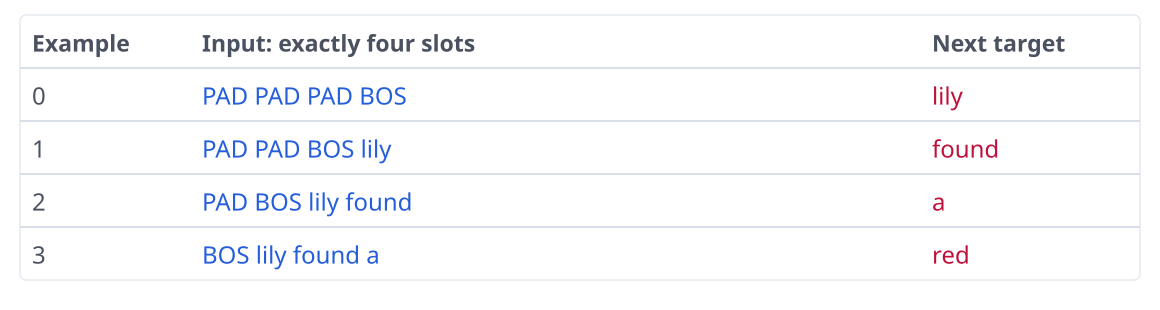

In [12]:
contexts, targets = [], []
for t in range(1, len(ids)):
    visible = ids[max(0, t-w):t]
    contexts.append([vocab.pad_id]*(w-len(visible)) + visible)
    targets.append(ids[t])

show_figure('windows-first', globals())

<a id='windows-last'></a>

## 12 · Later prefixes drop their oldest tokens

**2. Windows and batches** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/16/0)

The remaining three examples use full windows. The final target is EOS. No context crosses the end of this story into a different document.

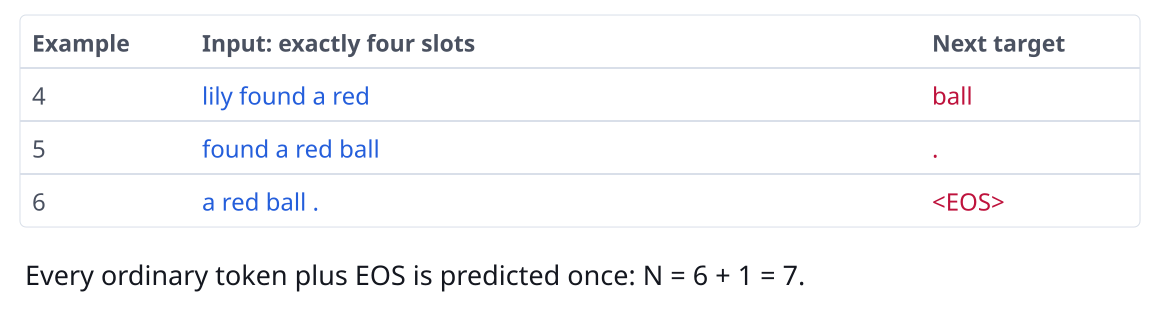

In [13]:
all_X = torch.tensor(contexts, dtype=torch.long)
all_y = torch.tensor(targets, dtype=torch.long)
N = len(all_y)
assert N == 7 and all_X.shape == (7, 4)
assert not all_y.eq(vocab.pad_id).any()

show_figure('windows-last', globals())

<a id='counts'></a>

## 13 · Counting the supervised examples

**2. Windows and batches** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/17/0)

With left-padding and one EOS target per story, T ordinary tokens give T+1 examples. Add this count over documents. These larger counts come from the saved corpus audit.

<details><summary>Check yourself: Does w=8 create more targets than w=4 here?</summary>No. With this padding rule, both give seven targets. A wider window changes the visible input history, not the target count.</details>

{'test': 120393, 'train': 969160, 'validation': 120220}


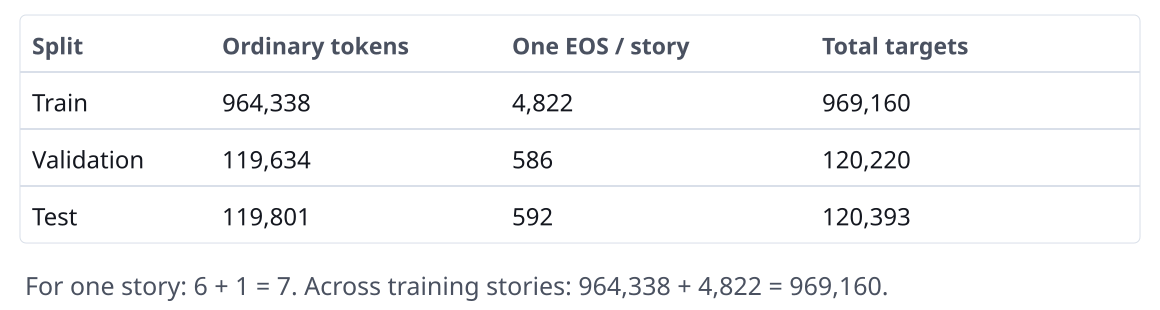

In [14]:
window_counts = {
    split: audit['oov'][split]['tokens'] + count
    for split, count in audit['documents'].items()
}
assert window_counts['train'] == 969160
print(window_counts)

show_figure('counts', globals())

<a id='context'></a>

## 14 · Context length controls what is visible

**2. Windows and batches** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/18/0)

History is everything already known. The context window is the suffix read for this prediction. Increasing w can recover an older clue, but also changes model size or computation.

{2: [9, 6], 4: [7, 5, 9, 6], 6: [1, 8, 7, 5, 9, 6]}


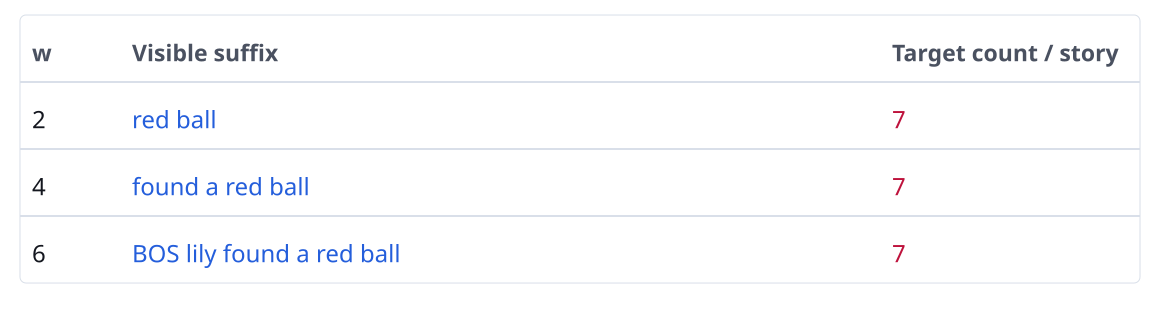

In [15]:
history = ids[:6]  # BOS lily found a red ball
contexts_by_width = {width: history[-width:] for width in [2, 4, 6]}
print(contexts_by_width)

show_figure('context', globals())

<a id='batch'></a>

## 15 · A real batch with B=2

**2. Windows and batches** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/19/0)

A batch stacks two independent training examples. B counts examples, not words, stories or context slots. Both models will receive these exact same X and y tensors.

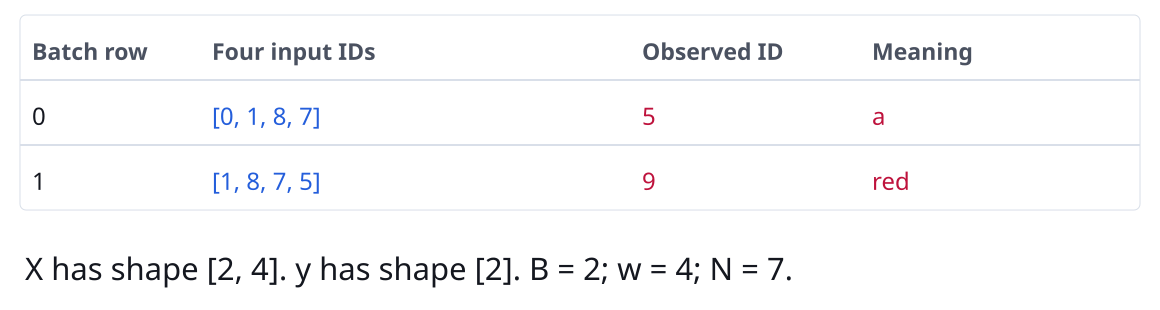

In [16]:
selected = torch.tensor([2, 3])
X, y = all_X[selected], all_y[selected]
B = X.shape[0]
assert X.tolist() == [[0, 1, 8, 7], [1, 8, 7, 5]]
assert y.tolist() == [5, 9] and B == 2

show_figure('batch', globals())

<a id='batches'></a>

## 16 · Seven examples do not mean seven optimizer steps

**2. Windows and batches** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/20/0)

A simple loader with B=2 and drop_last=False makes four batches in one pass: 2, 2, 2 and 1 example. The real benchmark instead samples B=512 windows per step with replacement.

One sequential pass: [2, 2, 2, 1]
Benchmark target presentations: 3072000


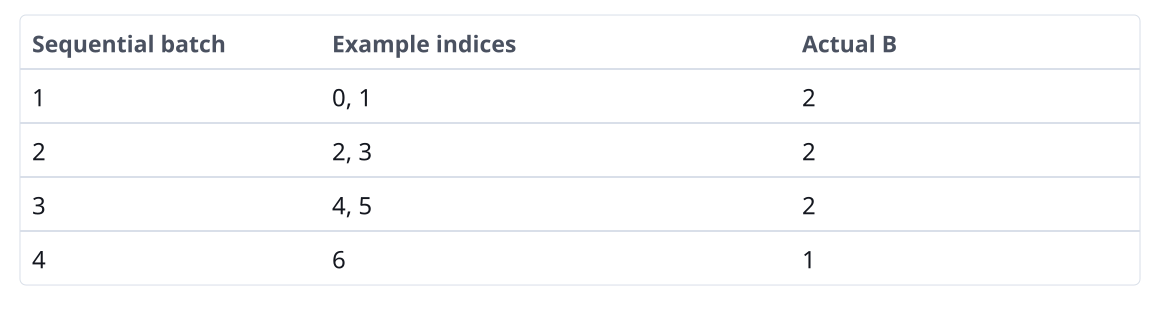

In [17]:
batch_sizes = [len(all_y[start:start+B]) for start in range(0, N, B)]
assert batch_sizes == [2, 2, 2, 1]
print('One sequential pass:', batch_sizes)
print('Benchmark target presentations:', 6000 * 512)

show_figure('batches', globals())

<a id='shapes'></a>

## 17 · Concrete dimensions for the worked batch

**2. Windows and batches** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/21/0)

The batch and context axes describe the data. The representation widths are model choices. The vocabulary size is the number of output classes, including special tokens.

<details><summary>Check yourself: Must d_k equal d_v?</summary>No. Queries and keys need the same width for their dot product. Values may have a different width. Here d_k=3 and d_v=2.</details>

{'B': 2, 'w': 4, 'C': 10, 'd': 4, 'h': 8, 'd_k': 3, 'd_v': 2}


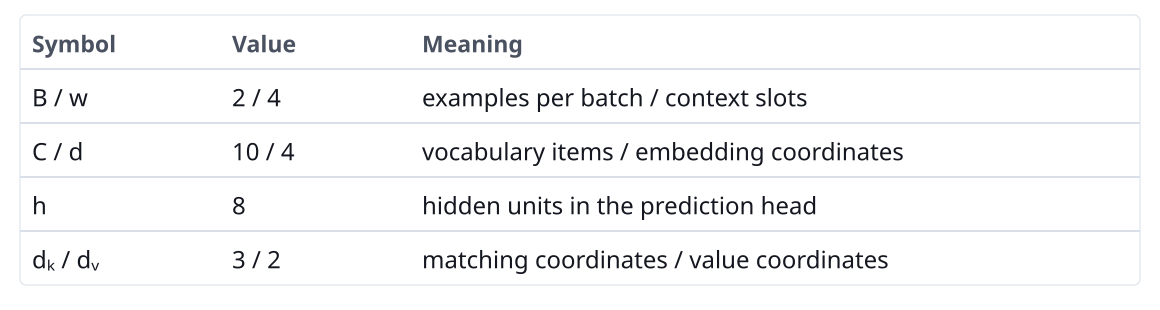

In [18]:
d, h, d_k, d_v = 4, 8, 3, 2
torch.manual_seed(11)
mlp = FixedWindowMLP(C, w, d, h, vocab.pad_id)
torch.manual_seed(11)
attention = CausalAttentionLM(C, w, d, d_k, d_v, h, vocab.pad_id)
print(dict(B=B, w=w, C=C, d=d, h=h, d_k=d_k, d_v=d_v))

show_figure('shapes', globals())

<a id='mlp-map'></a>

## 18 · The full MLP training map

**3. The MLP forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/22/0)

We have prepared X and y. Follow X through the network. The observed target bypasses the network and joins the logits at the loss. The purple loop updates every learned layer.

X: (2, 4) y: (2,)


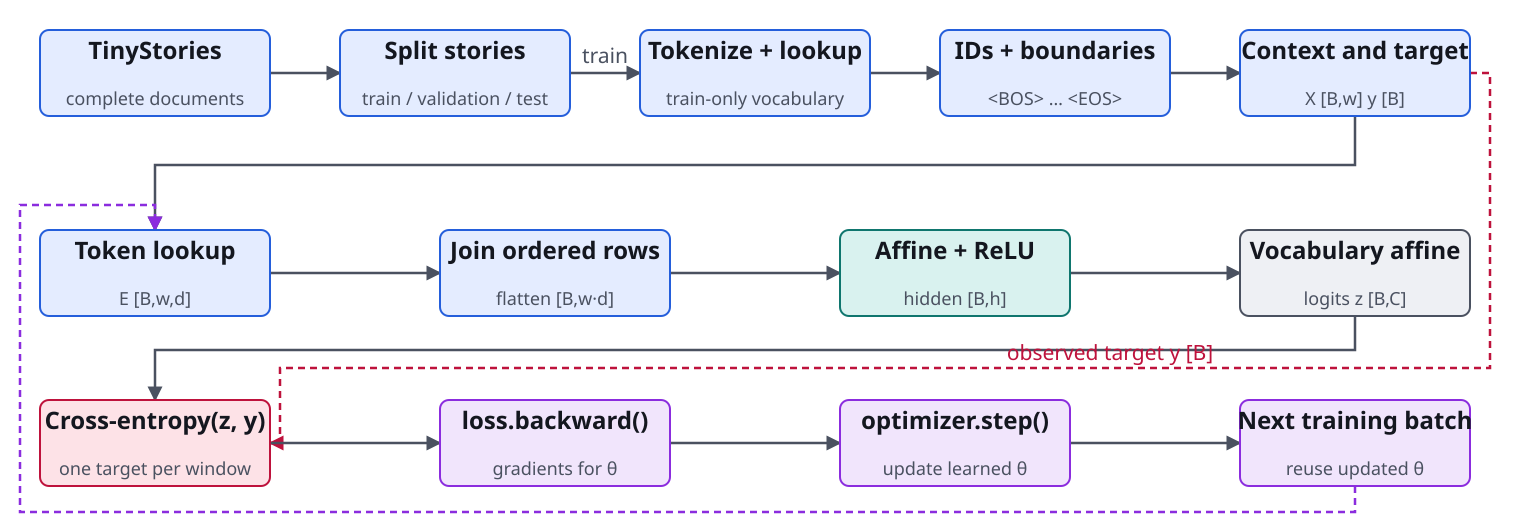

In [19]:
print('X:', tuple(X.shape), 'y:', tuple(y.shape))

show_figure('mlp-map', globals())

<a id='lookup'></a>

## 19 · An ID selects one embedding row

**3. The MLP forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/23/0)

The embedding table has C=10 rows and d=4 columns. ID 7, found, selects one four-number row. The four coordinates below are learned features with no assigned word meanings.

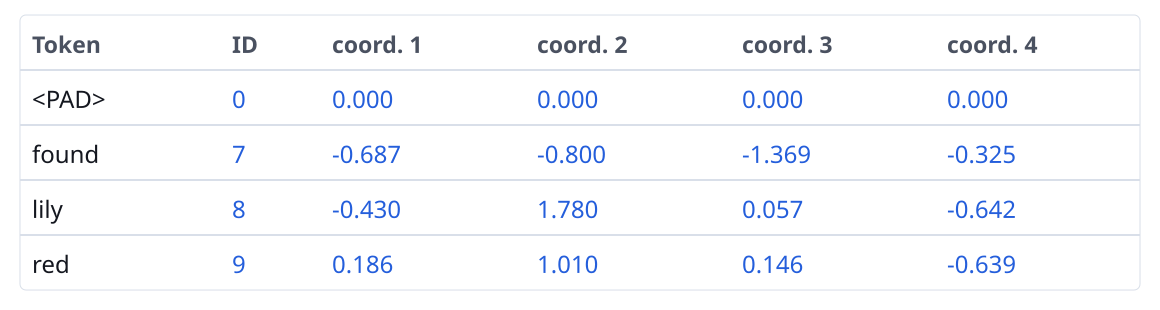

In [20]:
embedding_table = mlp.token_embedding.weight
found_id = vocab.stoi['found']
found_vector = embedding_table[found_id]
assert found_vector.shape == (4,)

show_figure('lookup', globals())

<a id='embedding-batch'></a>

## 20 · The whole batch becomes a 2 × 4 × 4 tensor

**3. The MLP forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/24/0)

Each of the two examples has four token slots. Each slot receives four embedding coordinates. PAD uses the fixed zero row. The same token ID selects the same row wherever it occurs.

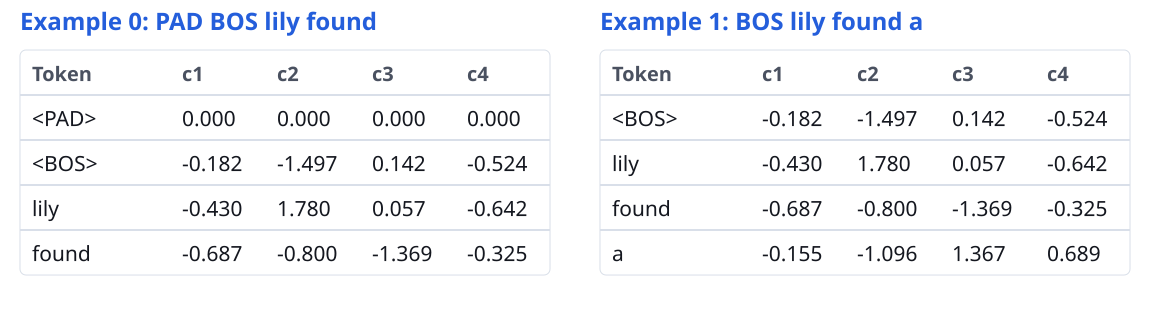

In [21]:
E_mlp = mlp.token_embedding(X)
assert E_mlp.shape == (2, 4, 4)
assert E_mlp[0, 0].eq(0).all()
assert torch.equal(E_mlp[0, 2], E_mlp[1, 1])  # lily

show_figure('embedding-batch', globals())

<a id='flatten'></a>

## 21 · Flatten the context axis, keep the batch axis

**3. The MLP forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/25/0)

Each example becomes one ordered row of 4×4=16 numbers. We never join example 0 to example 1. Swapping token positions changes which input connections receive each embedding.

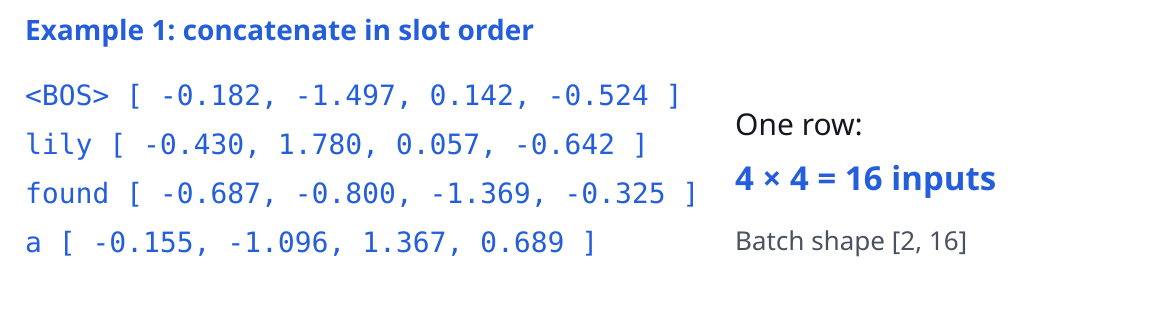

In [22]:
flat = E_mlp.flatten(start_dim=1)
assert flat.shape == (2, 16)
assert torch.equal(flat[1, :4], E_mlp[1, 0])

show_figure('flatten', globals())

<a id='hidden-affine'></a>

## 22 · One hidden neuron combines all sixteen inputs

**3. The MLP forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/26/0)

In row-vector notation the hidden matrix is 16×8. PyTorch stores Linear weights as 8×16. A neuron multiplies all sixteen input coordinates by its weights, sums them and adds one bias.

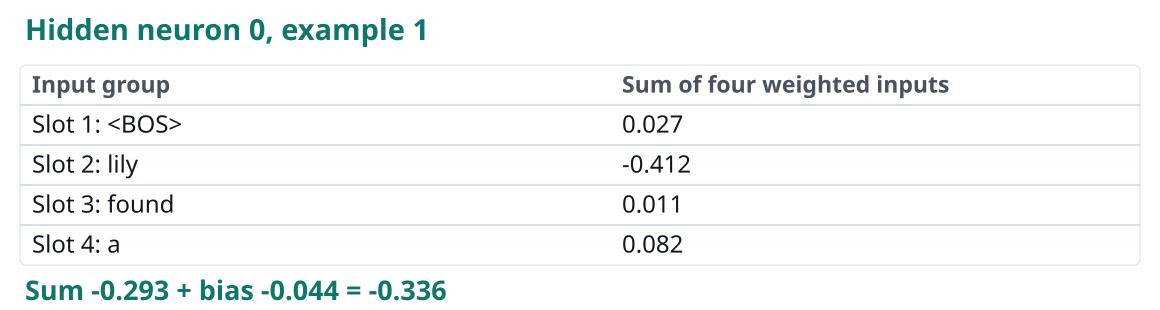

In [23]:
pre_hidden = mlp.hidden_layer(flat)
terms = flat[1] * mlp.hidden_layer.weight[0]
manual_hidden = terms.sum() + mlp.hidden_layer.bias[0]
assert torch.allclose(manual_hidden, pre_hidden[1, 0])

show_figure('hidden-affine', globals())

<a id='relu'></a>

## 23 · ReLU keeps positive activations

**3. The MLP forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/27/0)

ReLU acts separately on each hidden coordinate: max(0,z). It keeps the tensor shape at 2×8. The nonlinearity lets the network learn more than a single affine mapping.

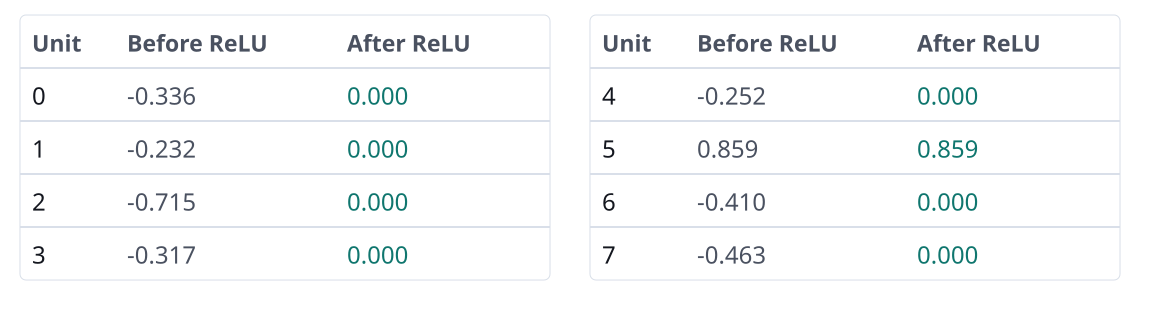

In [24]:
hidden_mlp = torch.relu(pre_hidden)
assert hidden_mlp.shape == (2, 8)
assert hidden_mlp.ge(0).all()

show_figure('relu', globals())

<a id='vocab-head'></a>

## 24 · Eight hidden numbers produce ten word scores

**3. The MLP forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/28/0)

Every vocabulary item gets a logit, including words that are not the target. The output matrix is 8×10 in row-vector notation. Logits can be negative and need not sum to one.

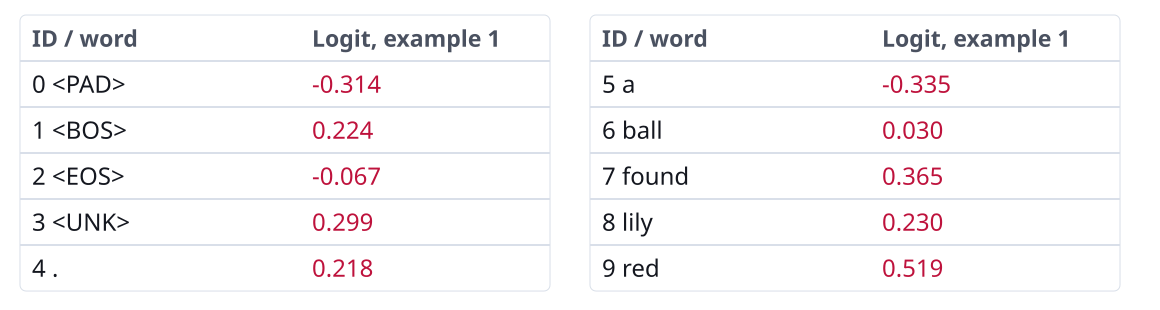

In [25]:
logits_mlp = mlp.vocab_head(hidden_mlp)
assert logits_mlp.shape == (2, 10)
assert torch.allclose(logits_mlp, mlp(X))

show_figure('vocab-head', globals())

<a id='attention-map'></a>

## 25 · The full attention training map

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/29/0)

The data, targets and loss stay the same. Attention changes how context reaches the hidden prediction layer. This one-layer implementation computes only the final query for each window.

Both architectures predict the same two targets: [5, 9]


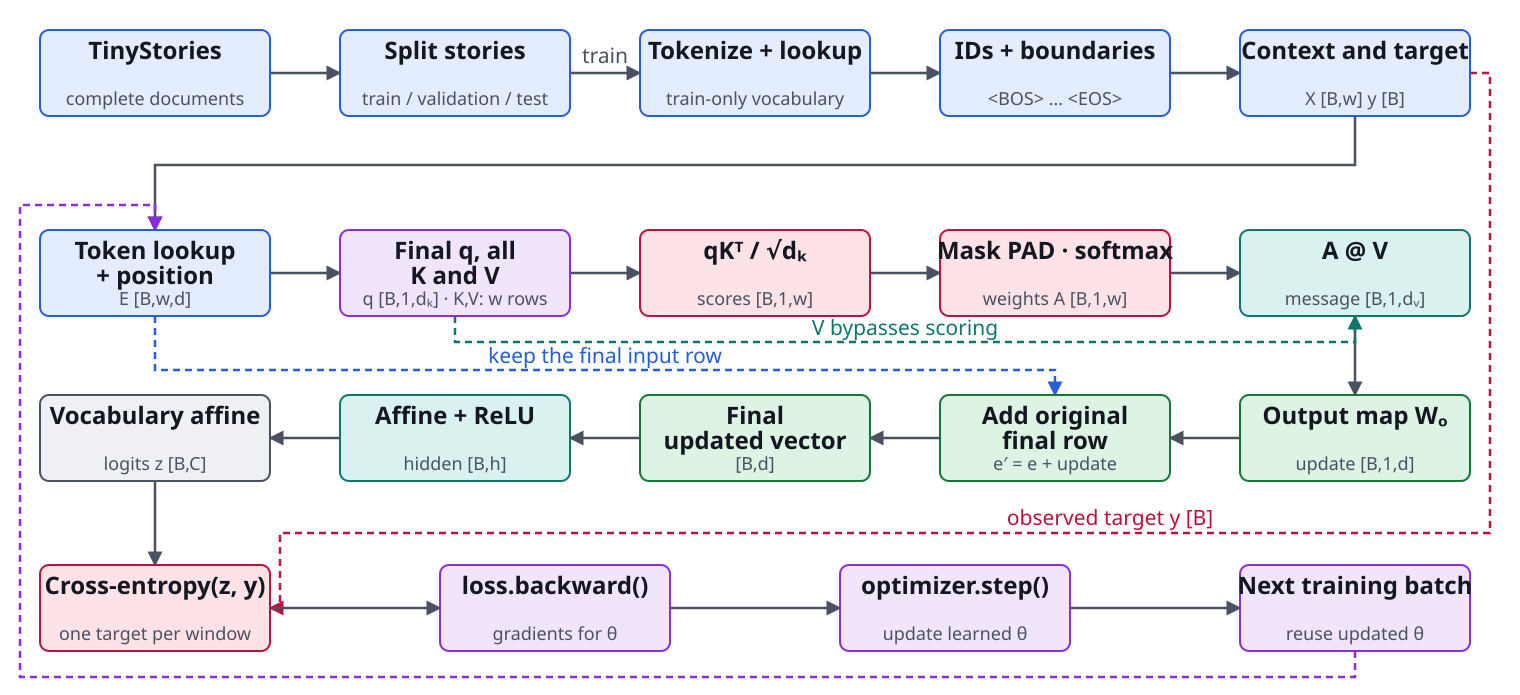

In [26]:
assert X.shape == (2, 4) and y.shape == (2,)
print('Both architectures predict the same two targets:', y.tolist())

show_figure('attention-map', globals())

<a id='positions'></a>

## 26 · Add a position vector to each token vector

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/30/0)

The position table has four rows, one for each context slot. Token and position vectors both have width four, so addition preserves the width. PAD keys will be masked even though position addition can make their input row nonzero.

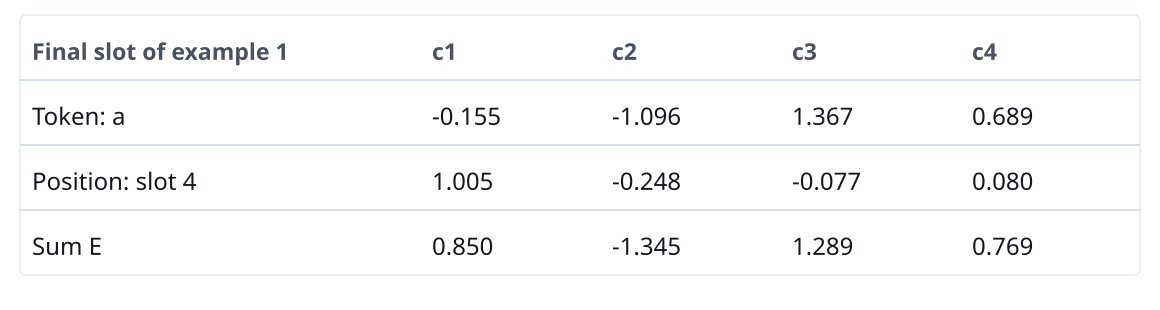

In [27]:
positions = torch.arange(w)
token_rows = attention.token_embedding(X)
position_rows = attention.position_embedding(positions)
E = token_rows + position_rows[None, :, :]
assert E.shape == (2, 4, 4)

show_figure('positions', globals())

<a id='query'></a>

## 27 · The final known token supplies one query

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/31/0)

For example 1 the final known token is a. Its four-number input row maps to three query coordinates. The unseen target red does not take part in this multiplication.

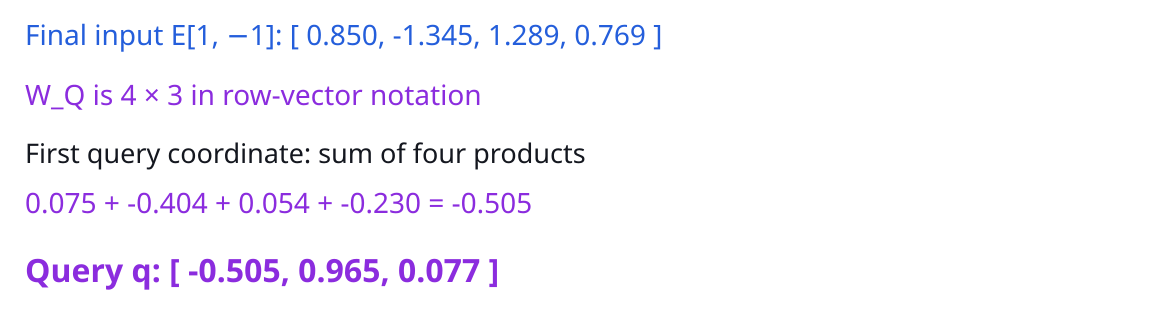

In [28]:
q = attention.W_Q(E[:, -1:, :])
query_terms = E[1, -1] * attention.W_Q.weight[0]
assert q.shape == (2, 1, 3)
assert torch.allclose(query_terms.sum(), q[1, 0, 0])

show_figure('query', globals())

<a id='keys'></a>

## 28 · Each source has a matching key

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/32/0)

All four source rows map to keys of width three. Query and key widths match because we will take their dot products. The same W_K applies at every source position and in both examples.

Row-vector W_K shape: (4, 3)


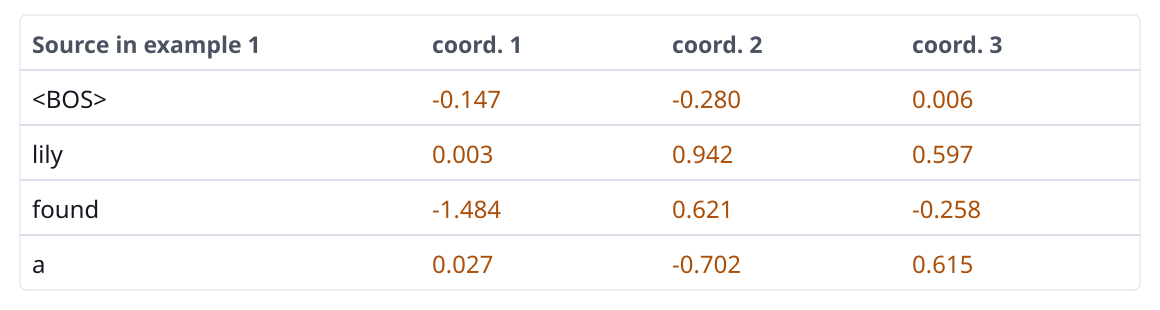

In [29]:
K = attention.W_K(E)
assert K.shape == (2, 4, 3)
print('Row-vector W_K shape:', tuple(attention.W_K.weight.T.shape))

show_figure('keys', globals())

<a id='values'></a>

## 29 · Each source also has information to send

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/33/0)

W_V maps each source to a two-number value. These coordinates carry information into the weighted message. They do not enter the query-key dot product.

Row-vector W_V shape: (4, 2)


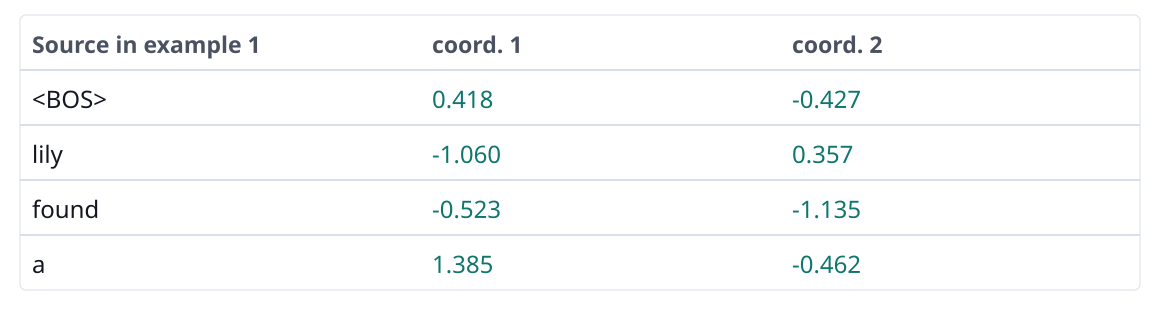

In [30]:
V = attention.W_V(E)
assert V.shape == (2, 4, 2)
print('Row-vector W_V shape:', tuple(attention.W_V.weight.T.shape))

show_figure('values', globals())

<a id='scores'></a>

## 30 · Compare the query with all four keys

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/34/0)

Each score is a three-term dot product divided by √3. The result has one row of four source scores per example. These are source-match scores, not vocabulary logits.

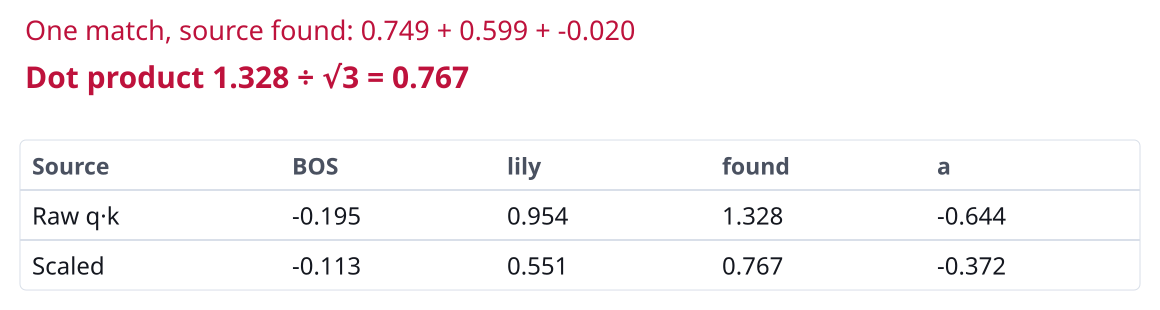

In [31]:
raw_scores = q @ K.transpose(-2, -1)
scores = raw_scores / math.sqrt(d_k)
dot_terms = q[1, 0] * K[1, 2]
assert torch.allclose(dot_terms.sum(), raw_scores[1, 0, 2])
assert scores.shape == (2, 1, 4)

show_figure('scores', globals())

<a id='mask'></a>

## 31 · Padding must receive zero attention weight

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/35/0)

Example 0 has PAD in its first slot, so that score becomes −∞. All slots of example 1 are real tokens. Since these are final queries, their windows contain no future columns.

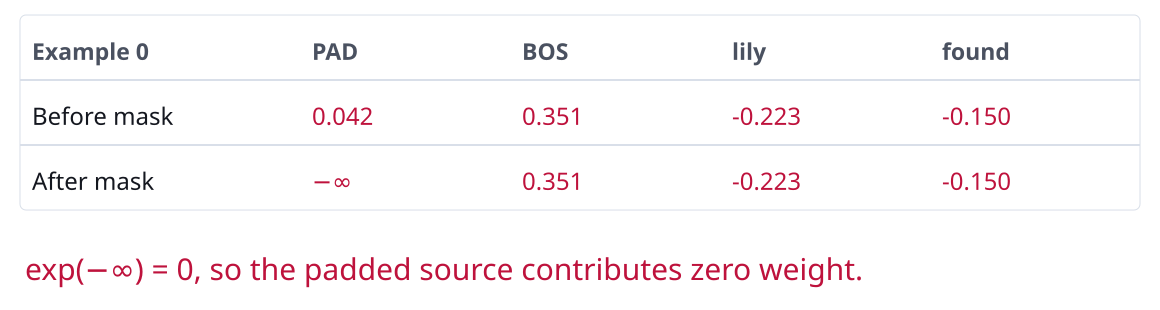

In [32]:
pad_mask = X[:, None, :].eq(vocab.pad_id)
masked_scores = scores.masked_fill(pad_mask, float('-inf'))
assert torch.isneginf(masked_scores[0, 0, 0])

show_figure('mask', globals())

<a id='attention-softmax'></a>

## 32 · Softmax turns four source scores into weights

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/36/0)

Subtract the largest score, exponentiate and divide by the row sum. This softmax runs over context slots. Later, a different softmax will run over vocabulary items.

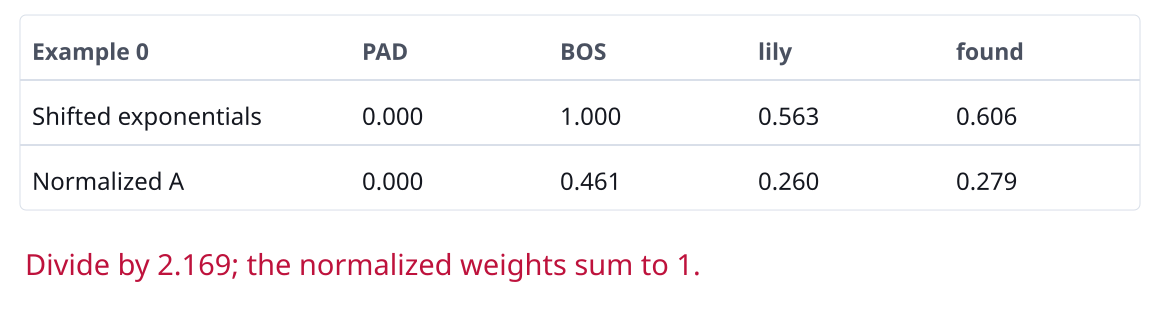

In [33]:
source_exp = (masked_scores - masked_scores.amax(-1, keepdim=True)).exp()
A = source_exp / source_exp.sum(-1, keepdim=True)
assert torch.allclose(A, masked_scores.softmax(-1))
assert A[0, 0, 0] == 0 and torch.allclose(A.sum(-1), torch.ones(2, 1))

show_figure('attention-softmax', globals())

<a id='mix'></a>

## 33 · Each weight scales a complete value row

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/37/0)

For example 1, multiply each two-number value by its source weight and add the four contributions. The result is one two-number message. Weighting does not change the value width.

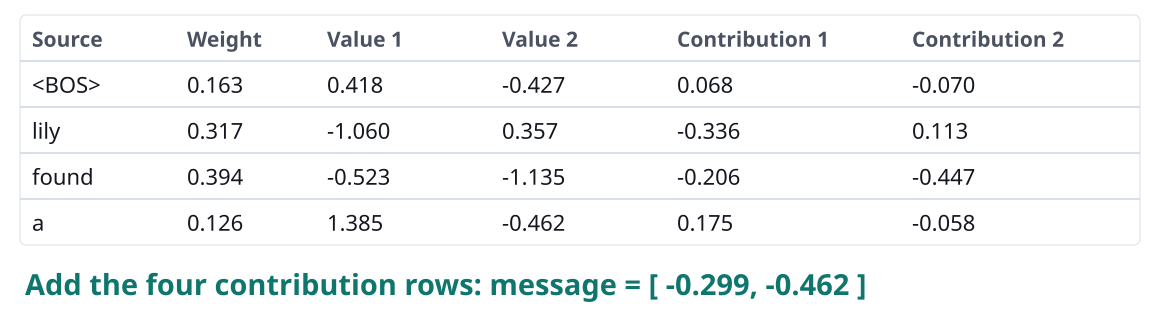

In [34]:
contributions = A[1, 0, :, None] * V[1]
message = A @ V
assert message.shape == (2, 1, 2)
assert torch.allclose(contributions.sum(0), message[1, 0])

show_figure('mix', globals())

<a id='output-map'></a>

## 34 · Project two message coordinates into four

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/38/0)

The message has width two, but the original input has width four. The learned W_O is 2×4 in row-vector notation. Every output coordinate can combine both message coordinates.

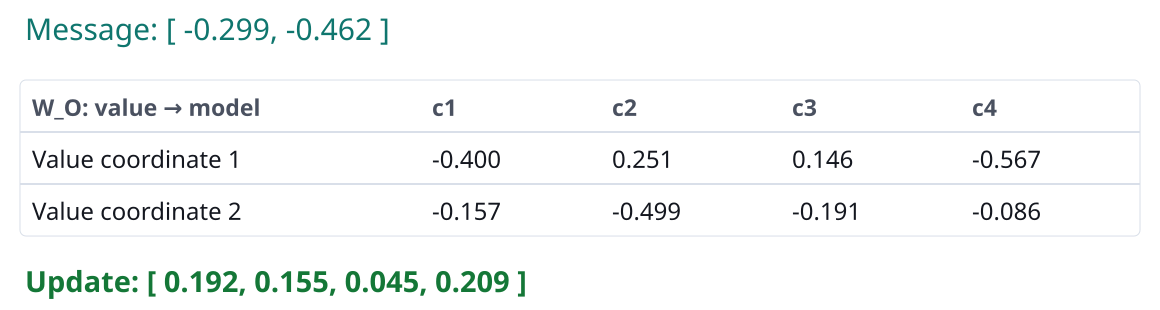

In [35]:
update = attention.W_O(message).squeeze(1)
assert update.shape == (2, 4)
assert torch.allclose(message[1, 0] @ attention.W_O.weight.T, update[1])

show_figure('output-map', globals())

<a id='residual'></a>

## 35 · Add the update to the original final row

**4. The attention forward pass** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/39/0)

The residual addition now combines two vectors with the same width. The updated row enters an eight-unit ReLU layer and then the ten-class vocabulary head, just as in the MLP path.

<details><summary>Check yourself: Is the two-number message already a prediction?</summary>No. W_O maps it to four coordinates, the residual adds the original row, and the hidden vocabulary head produces ten logits.</details>

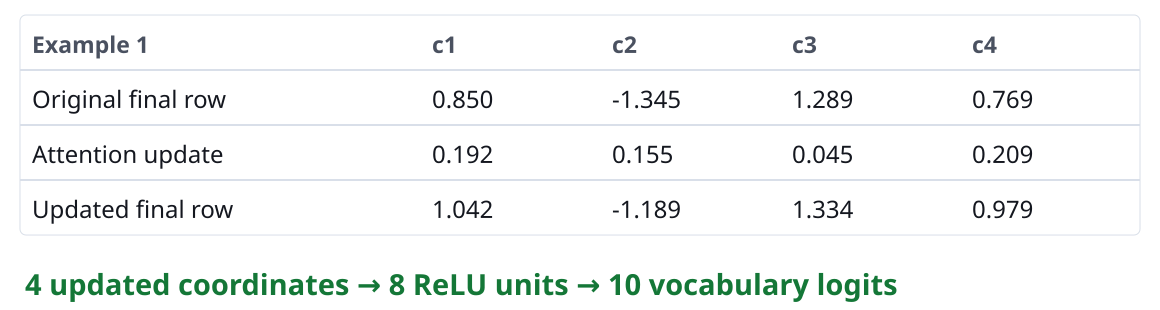

In [36]:
final = E[:, -1, :] + update
hidden_att = torch.relu(attention.hidden_layer(final))
logits_att = attention.vocab_head(hidden_att)
assert torch.allclose(logits_att, attention(X), atol=1e-6)
assert torch.allclose(logits_att, attention.forward_details(X)['logits'], atol=1e-6)

show_figure('residual', globals())

<a id='word-softmax'></a>

## 36 · Ten logits become ten next-token probabilities

**5. Loss and learning** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/40/0)

For the MLP example with target red, apply vocabulary softmax. The denominator includes all ten classes. These values come from the seeded model before training. Even a correct guess here can occur by chance.

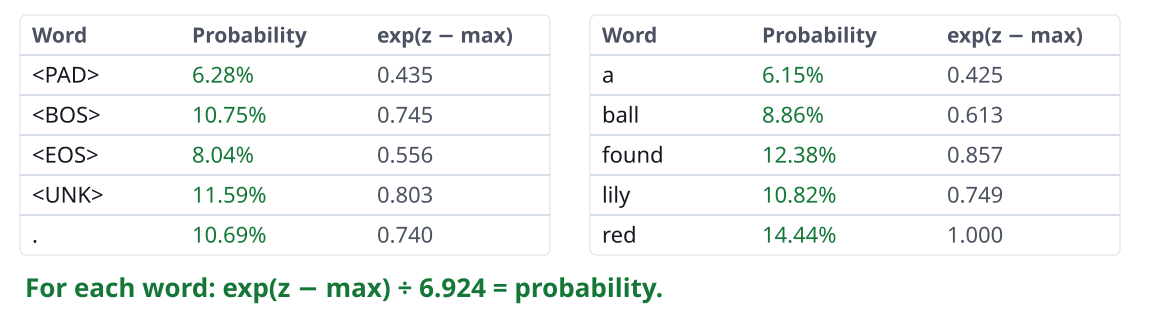

In [37]:
word_exp = (logits_mlp[1] - logits_mlp[1].max()).exp()
p = word_exp / word_exp.sum()
assert torch.allclose(p, logits_mlp[1].softmax(-1))
assert torch.allclose(p.sum(), torch.tensor(1.0))

show_figure('word-softmax', globals())

<a id='target'></a>

## 37 · The text gives the target; the model gives a guess

**5. Loss and learning** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/41/0)

Argmax returns the largest-probability vocabulary ID. The target remains red because the corpus contains red after this prefix. Training does not replace that observed target with the model’s guess.

Guess: red target: red
Probability of target: 0.1444295048713684


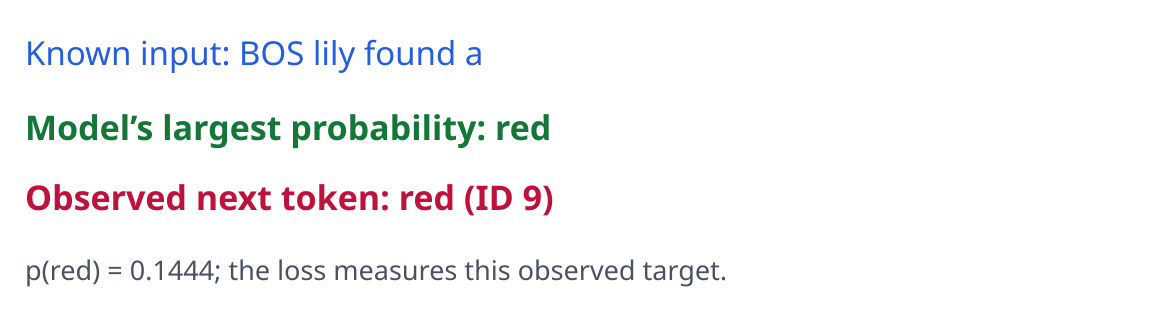

In [38]:
guess_id = int(p.argmax())
target_id = int(y[1])
print('Guess:', words[guess_id], 'target:', words[target_id])
print('Probability of target:', float(p[target_id].detach()))

show_figure('target', globals())

<a id='loss'></a>

## 38 · Two targets give two losses, then one batch mean

**5. Loss and learning** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/42/0)

For each example, cross-entropy is −log of the probability assigned to its observed target. PyTorch accepts raw logits and performs log-softmax internally. The optimizer uses the mean across B=2 examples.

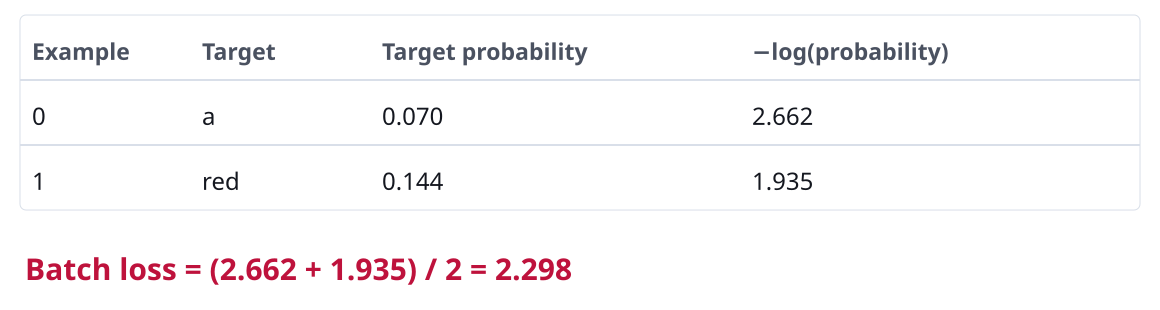

In [39]:
losses = F.cross_entropy(logits_mlp, y, reduction='none')
loss = losses.mean()
manual_loss = -logits_mlp.log_softmax(-1)[torch.arange(B), y]
assert torch.allclose(losses, manual_loss)

show_figure('loss', globals())

<a id='gradient'></a>

## 39 · Backward computes a direction for every parameter

**5. Loss and learning** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/43/0)

For vocabulary weight W[j,r], the batch-mean gradient is the mean of (p_r − 1[y=r]) × hidden_j. Here we inspect the weight feeding the red logit from hidden unit 0.

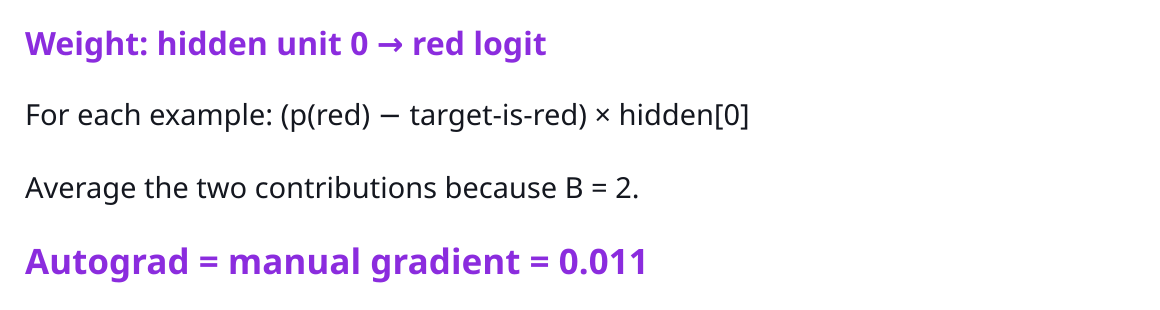

In [40]:
mlp.zero_grad(set_to_none=True)
loss.backward()
manual_grad = ((logits_mlp.softmax(-1)[:, 9] - y.eq(9).float()) * hidden_mlp[:, 0]).mean()
grad = mlp.vocab_head.weight.grad[9, 0]
assert torch.allclose(grad, manual_grad)

show_figure('gradient', globals())

<a id='update'></a>

## 40 · One optimizer step changes the stored weights

**5. Loss and learning** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/44/0)

For this arithmetic demonstration we use SGD with learning rate 0.1: new weight = old weight − 0.1×gradient. The measured TinyStories runs use validation-tuned AdamW instead.

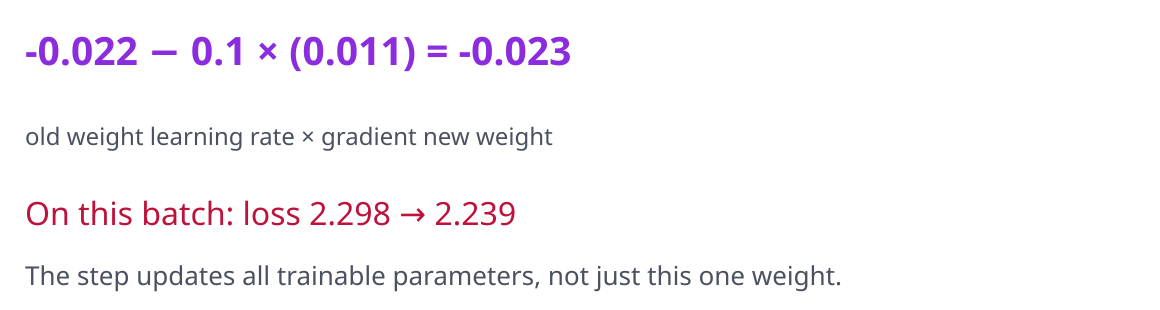

In [41]:
old_weight = mlp.vocab_head.weight[9, 0].detach().clone()
before_loss = float(loss.detach())
optimizer = torch.optim.SGD(mlp.parameters(), lr=0.1)
optimizer.step()
new_weight = mlp.vocab_head.weight[9, 0].detach().clone()
after_loss = float(F.cross_entropy(mlp(X), y).detach())
assert torch.allclose(new_weight, old_weight - 0.1*grad)

show_figure('update', globals())

<a id='training-loop'></a>

## 41 · Many batches, with validation between checkpoints

**5. Loss and learning** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/45/0)

The actual trainer samples 512 training windows per step, computes the loss, backpropagates and updates parameters. Validation selects the best saved checkpoint. The test set does not choose a checkpoint.

Maximum steps: 6000 batch size: 512
Maximum target presentations: 3072000
Checkpoint rule: best validation loss


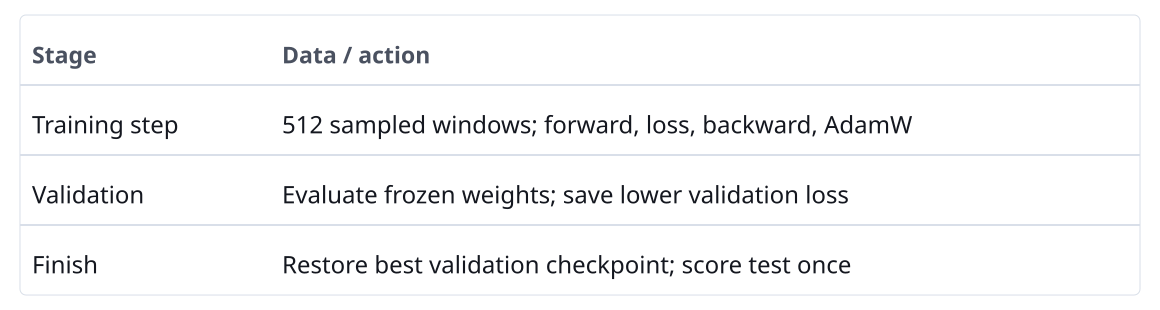

In [42]:
benchmark = evidence['benchmark']
print('Maximum steps:', 6000, 'batch size:', 512)
print('Maximum target presentations:', 6000*512)
print('Checkpoint rule: best validation loss')

show_figure('training-loop', globals())

<a id='evaluation'></a>

## 42 · Held-out scoring and free-running generation

**6. Inference** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/46/0)

Held-out scoring uses observed X,y pairs and records loss. Generation has a prompt but no observed next target. Both freeze parameters. Neither calls backward or optimizer.step.

Illustrative scoring loss: 2.2394907474517822


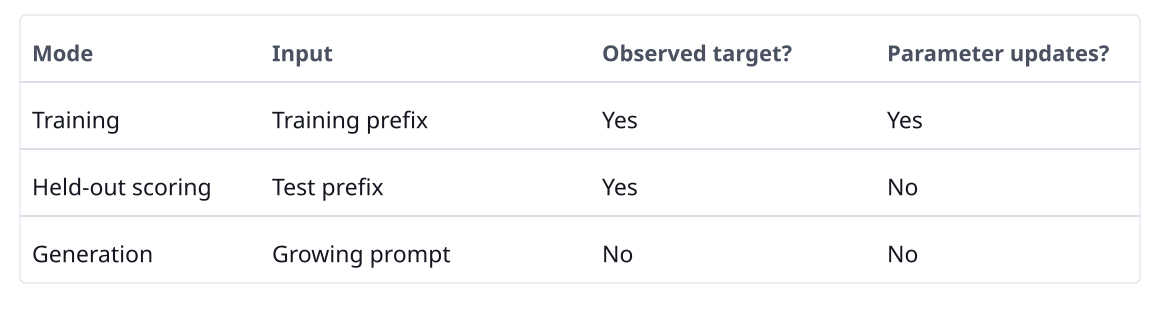

In [43]:
mlp.eval()
with torch.inference_mode():
    frozen_loss = F.cross_entropy(mlp(X), y)
print('Illustrative scoring loss:', float(frozen_loss))

show_figure('evaluation', globals())

<a id='mlp-inference'></a>

## 43 · The complete MLP generation loop

**6. Inference** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/47/0)

Load the same vocabulary and trained parameters. Prepare the latest window, predict, choose a token and append it. Stop on EOS or the generation budget. The only changing state is the history.

Generation uses B=1; the parameters stay fixed.


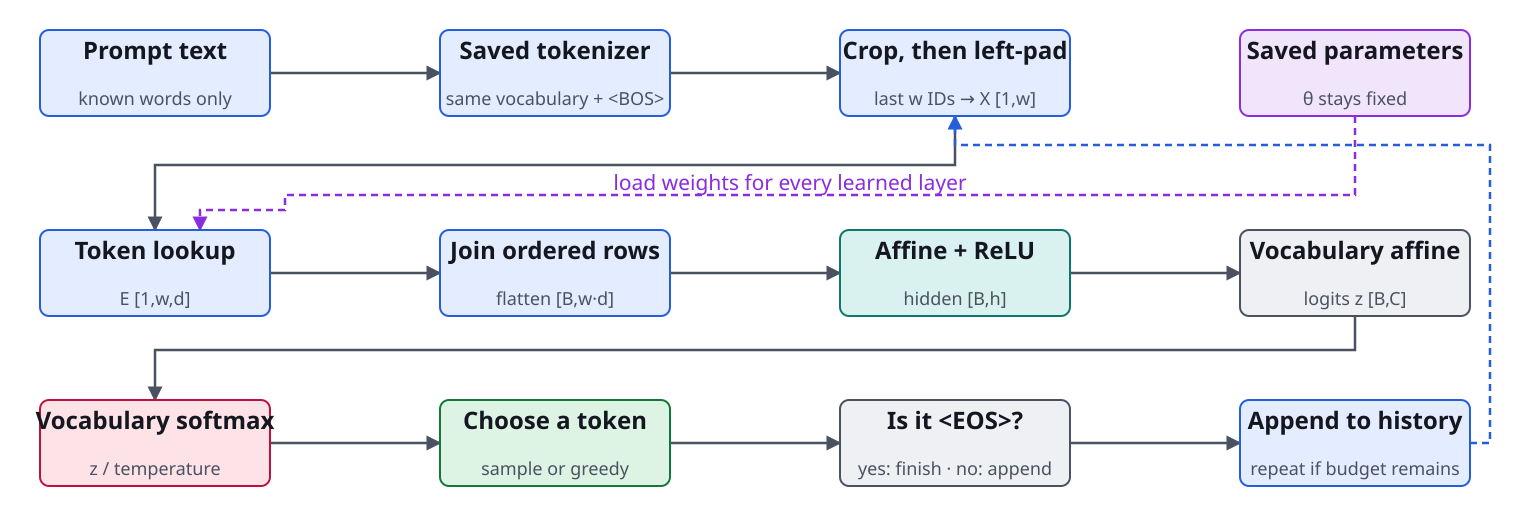

In [44]:
print('Generation uses B=1; the parameters stay fixed.')

show_figure('mlp-inference', globals())

<a id='attention-inference'></a>

## 44 · Attention uses the same generation loop

**6. Inference** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/48/0)

The new final token supplies the next query. This notebook recomputes the current window and has no KV cache. Position indices describe the slots in that current window.

Final query only; all available keys and values; no KV cache.


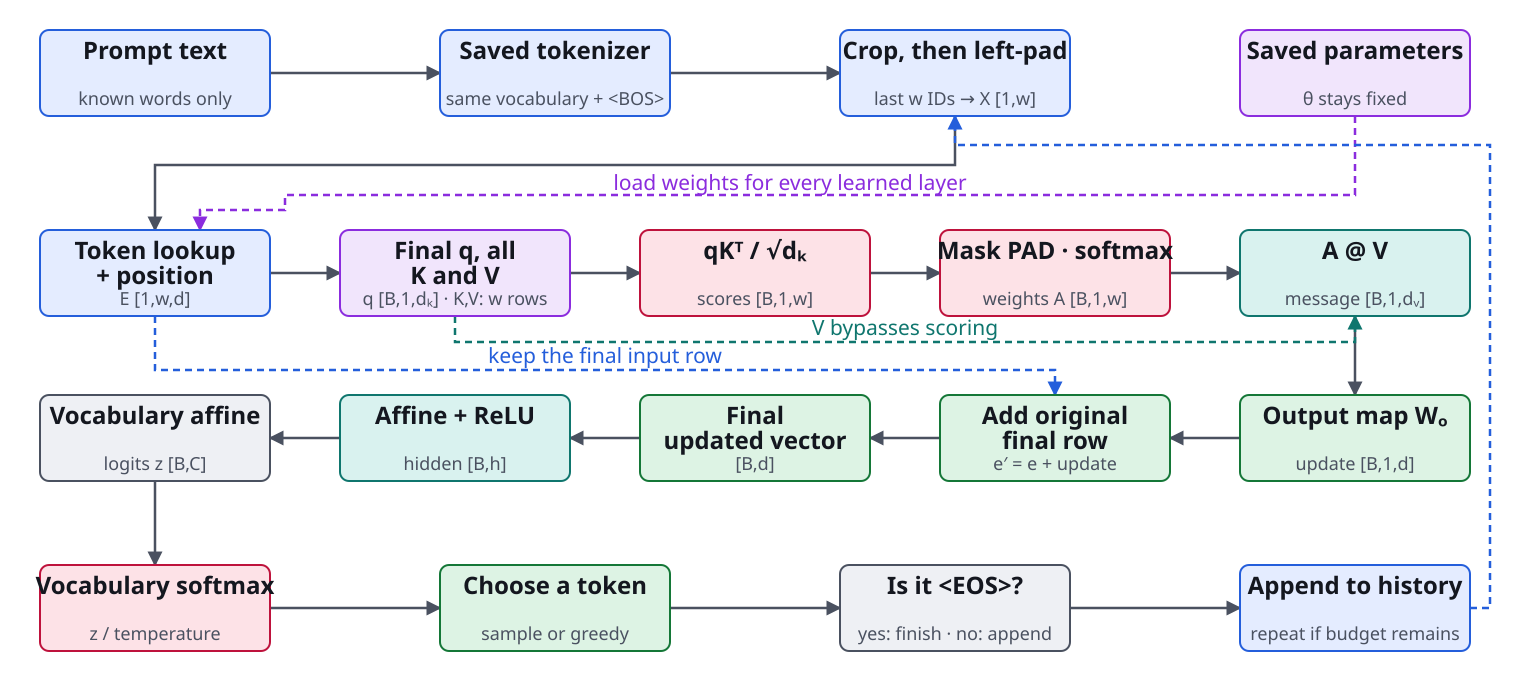

In [45]:
attention.eval()
print('Final query only; all available keys and values; no KV cache.')

show_figure('attention-inference', globals())

<a id='prompt'></a>

## 45 · Prepare a prompt using the same rules

**6. Inference** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/49/0)

For a short prompt, prepend BOS once and left-pad to w=4. Do not append EOS to an unfinished prompt. For a long prompt, keep only its most recent four IDs.

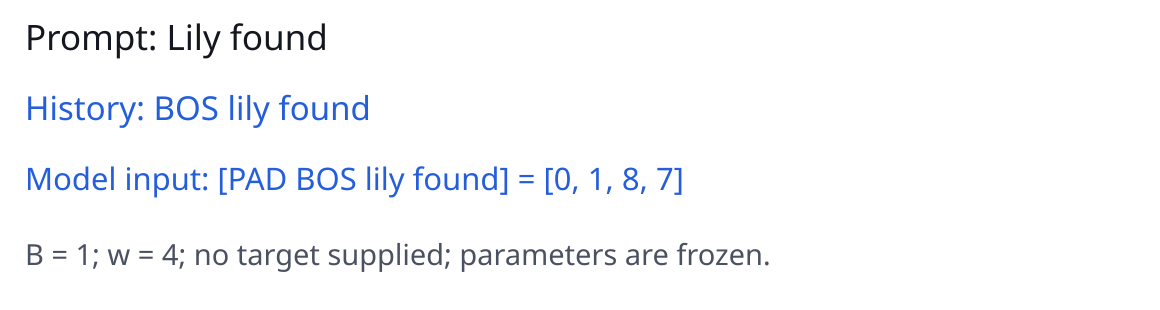

In [46]:
prompt = 'Lily found'
history = [vocab.bos_id] + vocab.encode_tokens(tokenize(prompt), boundaries=False)
kept = history[-w:]
inference_X = torch.tensor([[vocab.pad_id]*(w-len(kept)) + kept])
assert inference_X.tolist() == [[0, 1, 8, 7]]

show_figure('prompt', globals())

<a id='decode'></a>

## 46 · Greedy decoding and sampling make different choices

**6. Inference** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/50/0)

Mask PAD, BOS and UNK as generation candidates, then normalize the remaining logits. Greedy selects the maximum. Sampling selects according to probability. The fixed draw u=0.8 below makes the sampling calculation reproducible.

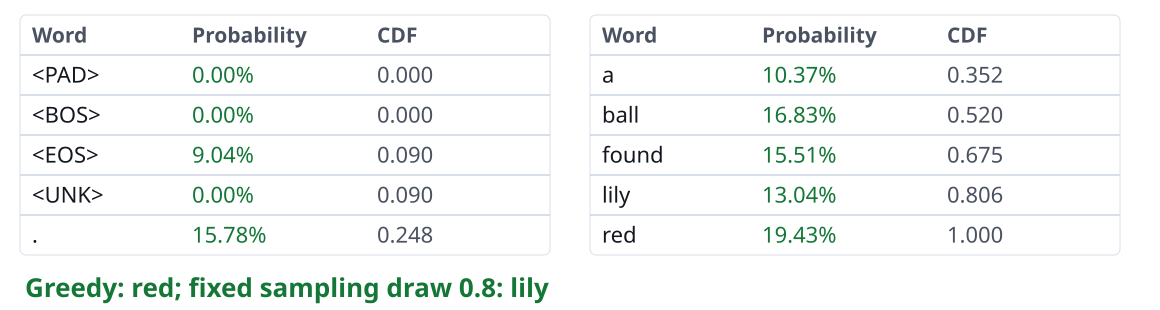

In [47]:
with torch.inference_mode():
    next_logits = mlp(inference_X)[0]
    next_logits[[vocab.pad_id, vocab.bos_id, vocab.unk_id]] = float('-inf')
    next_p = next_logits.softmax(-1)
greedy_id = int(next_p.argmax())
cdf = next_p.cumsum(0)
sample_id = int(torch.searchsorted(cdf, torch.tensor(0.8)))

show_figure('decode', globals())

<a id='append'></a>

## 47 · The chosen token becomes input on the next step

**6. Inference** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/51/0)

Check EOS before appending. If generation continues, append the selected ID, crop and pad again. A longer history does not change w. This four-step trace uses the tiny teaching model, not a language-quality benchmark.

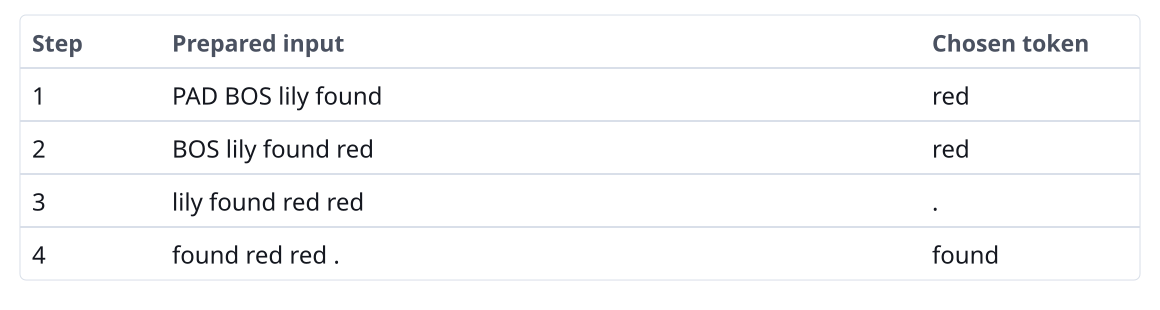

In [48]:
frozen = {n:p.detach().clone() for n,p in mlp.named_parameters()}
generation_trace = []
with torch.inference_mode():
    for generation_step in range(4):
        kept = history[-w:]
        x_next = torch.tensor([[vocab.pad_id]*(w-len(kept)) + kept])
        z_next = mlp(x_next)[0]
        z_next[[0, 1, 3]] = float('-inf')
        chosen = int(z_next.argmax())
        generation_trace.append((x_next[0].tolist(), chosen))
        if chosen == vocab.eos_id: break
        history.append(chosen)
assert all(torch.equal(p, frozen[n]) for n,p in mlp.named_parameters())

show_figure('append', globals())

<a id='benchmark'></a>

## 48 · The trained TinyStories comparison

**7. The real experiment** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/52/0)

The saved experiment uses the same documents, vocabulary, targets and 64-token context for both models. Each model has validation-tuned optimizer settings. These are three-seed test results, separate from our ten-token arithmetic example.

mlp 51.414434800867234 +/- 0.44307967119606395
attention 31.31463254211675 +/- 0.3047408118077636


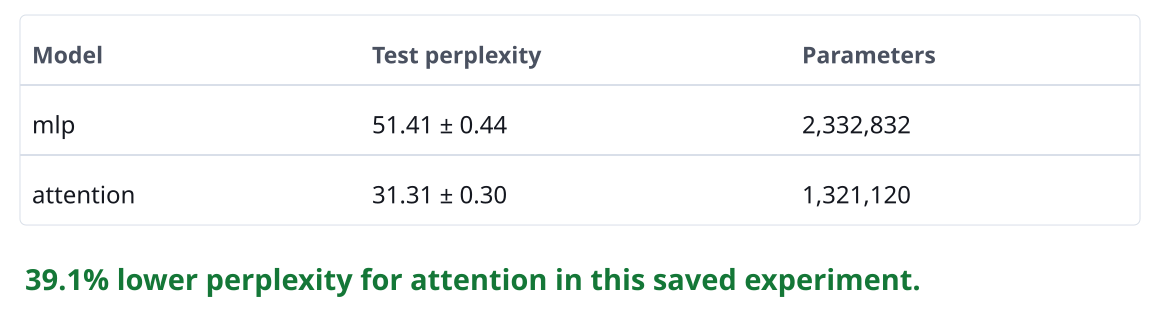

In [49]:
comparison = benchmark['aggregate']
for name in ['mlp', 'attention']:
    stats = comparison[name]['test_perplexity']
    print(name, stats['mean'], '+/-', stats['sample_std'])

show_figure('benchmark', globals())

<a id='next'></a>

## 49 · The same steps in the runnable notebooks

**7. The real experiment** · [Matching slide](https://nipunbatra.github.io/attention/attention.html?present#s19/53/0)

This notebook executes the small calculation behind every figure. Notebook 1 loads the corpus and trains the MLP. Notebook 3 trains attention. Notebook 4 checks the saved comparison and studies representations.

Toy example: 7 targets; worked batch: 2 examples.
Real experiment: 969,160 training windows; context 64; vocabulary 4,000.


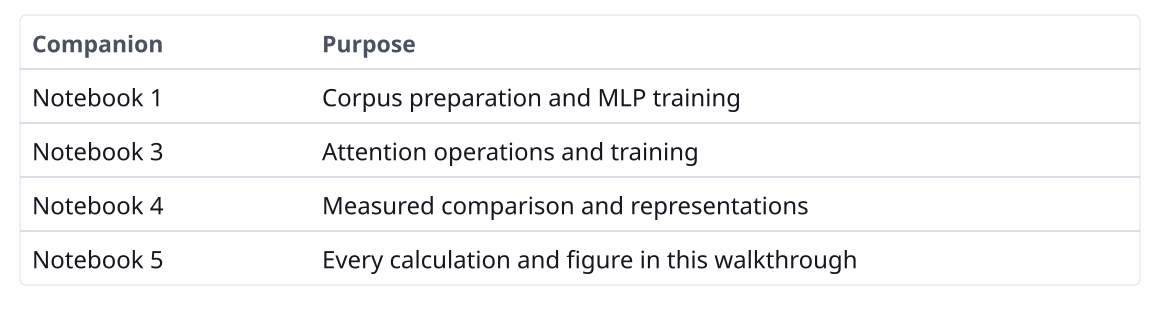

In [50]:
assert B == 2 and w == 4 and C == 10
print('Toy example: 7 targets; worked batch: 2 examples.')
print('Real experiment: 969,160 training windows; context 64; vocabulary 4,000.')

show_figure('next', globals())